In [1]:
# !pip install torch
# !pip install torchvision
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu129 -U
# !pip install pandas
!pip install torch-summary

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import csv
from torchsummary import summary
# Hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Recommended code block to check CUDA details ---

# Check if CUDA (GPU support) is available
if device == "cuda":
    # Get the number of available GPUs
    gpu_count = torch.cuda.device_count()
    print(f"CUDA is available. Using {gpu_count} GPU(s).")
    
    # Print the name of each GPU
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("CUDA not available. Using CPU.")

# --- End of recommended block ---

batch_size = 128
image_size = 64
channels_img = 1 # MNIST is grayscale
z_dim = 100 # Latent dimension (noise)
num_epochs = 50 # As required by the assignment

# Quick fix: Renamed 'transforms' variable to avoid conflict with the module
transform_pipeline = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(channels_img)], [0.5 for _ in range(channels_img)]),
])

dataset = datasets.MNIST(root="dataset/", train=True, transform=transform_pipeline, download=True)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,num_workers=8 )

CUDA is available. Using 1 GPU(s).
  GPU 0: NVIDIA GeForce RTX 5060


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, features_g * 16, 4, 1, 0, bias=False), # N x f_g*16 x 4 x 4
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 16, features_g * 8, 4, 2, 1, bias=False), # N x f_g*8 x 8 x 8
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False), # N x f_g*4 x 16 x 16
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False), # N x f_g*2 x 32 x 32
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, channels_img, 4, 2, 1, bias=False), # N x channels_img x 64 x 64
            nn.Tanh() # Output: [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

In [4]:
# (Keep the same architecture, just remove the final activation)
class Critic(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            # Input: N x channels_img x 64 x 64
            nn.Conv2d(channels_img, features_d, 4, 2, 1, bias=False), # N x f_d x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False), # N x f_d*2 x 16 x 16
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False), # N x f_d*4 x 8 x 8
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False), # N x f_d*8 x 4 x 4
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 8, 1, 4, 2, 0, bias=False), # N x 1 x 1 x 1
        )

    def forward(self, x):
        return self.net(x)

In [5]:
lr = 5e-5 # Lower learning rate is common for WGAN
# batch_size, image_size, etc. remain the same
critic_iterations = 5 # Train the critic 5 times for every generator training
clip_value = 0.01 # The value for weight clipping

# Initialize models
gen = Generator(z_dim, channels_img, 64).to(device)
critic = Critic(channels_img, 64).to(device)

# Optimizers --> Use RMSprop
opt_gen = optim.RMSprop(gen.parameters(), lr=lr)
opt_critic = optim.RMSprop(critic.parameters(), lr=lr)

In [6]:


# --- Print Generator Summary ---
# The Generator's input is the noise vector (z_dim, 1, 1)
print("------------------------------------------------------------")
print("                   WGAN Generator Summary")
print("------------------------------------------------------------")
summary(gen, (z_dim, 1, 1))


------------------------------------------------------------
                   WGAN Generator Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64, 64]           --
|    └─ConvTranspose2d: 2-1              [-1, 1024, 4, 4]          1,638,400
|    └─BatchNorm2d: 2-2                  [-1, 1024, 4, 4]          2,048
|    └─ReLU: 2-3                         [-1, 1024, 4, 4]          --
|    └─ConvTranspose2d: 2-4              [-1, 512, 8, 8]           8,388,608
|    └─BatchNorm2d: 2-5                  [-1, 512, 8, 8]           1,024
|    └─ReLU: 2-6                         [-1, 512, 8, 8]           --
|    └─ConvTranspose2d: 2-7              [-1, 256, 16, 16]         2,097,152
|    └─BatchNorm2d: 2-8                  [-1, 256, 16, 16]         512
|    └─ReLU: 2-9                         [-1, 256, 16, 16]         --
|    └─ConvTranspose2d: 2-10     

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64, 64]           --
|    └─ConvTranspose2d: 2-1              [-1, 1024, 4, 4]          1,638,400
|    └─BatchNorm2d: 2-2                  [-1, 1024, 4, 4]          2,048
|    └─ReLU: 2-3                         [-1, 1024, 4, 4]          --
|    └─ConvTranspose2d: 2-4              [-1, 512, 8, 8]           8,388,608
|    └─BatchNorm2d: 2-5                  [-1, 512, 8, 8]           1,024
|    └─ReLU: 2-6                         [-1, 512, 8, 8]           --
|    └─ConvTranspose2d: 2-7              [-1, 256, 16, 16]         2,097,152
|    └─BatchNorm2d: 2-8                  [-1, 256, 16, 16]         512
|    └─ReLU: 2-9                         [-1, 256, 16, 16]         --
|    └─ConvTranspose2d: 2-10             [-1, 128, 32, 32]         524,288
|    └─BatchNorm2d: 2-11                 [-1, 128, 32, 32]         256
|    └─ReLU: 2-12                        [-1, 128, 

In [7]:
print("                 WGAN Critic Summary")
print("------------------------------------------------------------")
summary(critic, (channels_img, image_size, image_size))

                 WGAN Critic Summary
------------------------------------------------------------
Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 1, 1]             --
|    └─Conv2d: 2-1                       [-1, 64, 32, 32]          1,024
|    └─LeakyReLU: 2-2                    [-1, 64, 32, 32]          --
|    └─Conv2d: 2-3                       [-1, 128, 16, 16]         131,072
|    └─BatchNorm2d: 2-4                  [-1, 128, 16, 16]         256
|    └─LeakyReLU: 2-5                    [-1, 128, 16, 16]         --
|    └─Conv2d: 2-6                       [-1, 256, 8, 8]           524,288
|    └─BatchNorm2d: 2-7                  [-1, 256, 8, 8]           512
|    └─LeakyReLU: 2-8                    [-1, 256, 8, 8]           --
|    └─Conv2d: 2-9                       [-1, 512, 4, 4]           2,097,152
|    └─BatchNorm2d: 2-10                 [-1, 512, 4, 4]           1,024
|    └─LeakyReLU: 2-11          

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 1, 1]             --
|    └─Conv2d: 2-1                       [-1, 64, 32, 32]          1,024
|    └─LeakyReLU: 2-2                    [-1, 64, 32, 32]          --
|    └─Conv2d: 2-3                       [-1, 128, 16, 16]         131,072
|    └─BatchNorm2d: 2-4                  [-1, 128, 16, 16]         256
|    └─LeakyReLU: 2-5                    [-1, 128, 16, 16]         --
|    └─Conv2d: 2-6                       [-1, 256, 8, 8]           524,288
|    └─BatchNorm2d: 2-7                  [-1, 256, 8, 8]           512
|    └─LeakyReLU: 2-8                    [-1, 256, 8, 8]           --
|    └─Conv2d: 2-9                       [-1, 512, 4, 4]           2,097,152
|    └─BatchNorm2d: 2-10                 [-1, 512, 4, 4]           1,024
|    └─LeakyReLU: 2-11                   [-1, 512, 4, 4]           --
|    └─Conv2d: 2-12                      [-1, 1, 1, 1]      

In [8]:
# Create a fixed noise vector to see the progression of the generator
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device) # We'll generate a grid of 8x8=64 images

In [9]:
# Before the training loop starts
G_losses = []
C_losses = []

In [10]:

# File to save losses
loss_file_path = "wgan_losses.csv"

# Open file and create a writer object
with open(loss_file_path, 'w', newline='') as f:
    writer = csv.writer(f)
    # Write the header row
    writer.writerow(["Epoch", "Generator_Loss", "Critic_Loss"])

print("WGAN TRAINING STARTED........")

# CORRECTED WGAN training loop
for epoch in range(num_epochs):
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        current_batch_size = real.shape[0]

        # === Train Critic ===
        for _ in range(critic_iterations):
            noise = torch.randn(current_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise)
            
            critic_real = critic(real).reshape(-1)
            critic_fake = critic(fake).reshape(-1)
            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake))
            
            critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

            # Clip critic weights
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

        # === Train Generator ===
        # FIX: Generate a NEW batch of fake images for the generator update.
        # This makes the code efficient and prevents runtime errors.
        noise = torch.randn(current_batch_size, z_dim, 1, 1).to(device)
        fake = gen(noise)
        output = critic(fake).reshape(-1)
        loss_gen = -torch.mean(output)
        
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    # --- End of Epoch ---
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss C: {loss_critic:.4f}, Loss G: {loss_gen:.4f}")

    # Save generated images and losses
    with torch.no_grad():
        fake_samples = gen(fixed_noise)
        from torchvision.utils import save_image
        save_image(fake_samples, f"gan_samples_WGAN/sample_epoch_{epoch+1}.png", normalize=True)
    
    # Append the losses for this epoch to the CSV file
    with open(loss_file_path, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, loss_gen.item(), loss_critic.item()])

print("Training completed and values saved into CSV file for later plotting of the graph.")

WGAN TRAINING STARTED........
Epoch [1/50] Loss C: -0.5229, Loss G: 0.4678
Epoch [2/50] Loss C: -1.3274, Loss G: 0.6647
Epoch [3/50] Loss C: -0.7877, Loss G: 0.6539
Epoch [4/50] Loss C: -1.3964, Loss G: 0.6927
Epoch [5/50] Loss C: -0.9832, Loss G: 0.6749
Epoch [6/50] Loss C: -1.4930, Loss G: 0.7351
Epoch [7/50] Loss C: -1.4909, Loss G: 0.7295
Epoch [8/50] Loss C: -0.6764, Loss G: -0.3067
Epoch [9/50] Loss C: -1.4957, Loss G: 0.7246
Epoch [10/50] Loss C: -1.5189, Loss G: 0.7371
Epoch [11/50] Loss C: -1.5180, Loss G: 0.7337
Epoch [12/50] Loss C: -1.4845, Loss G: 0.7211
Epoch [13/50] Loss C: -1.5227, Loss G: 0.7397
Epoch [14/50] Loss C: -1.5132, Loss G: 0.7337
Epoch [15/50] Loss C: -1.5128, Loss G: 0.7371
Epoch [16/50] Loss C: -0.4712, Loss G: 0.4576
Epoch [17/50] Loss C: -1.3529, Loss G: 0.6619
Epoch [18/50] Loss C: -1.4145, Loss G: 0.6882
Epoch [19/50] Loss C: -1.4499, Loss G: 0.7086
Epoch [20/50] Loss C: -1.5042, Loss G: 0.7356
Epoch [21/50] Loss C: -0.6891, Loss G: 0.1003
Epoch [22/50

Successfully loaded 50 epochs from wgan_losses.csv.
Plot saved successfully to 'Wgan_loss_plot_from_file.png'


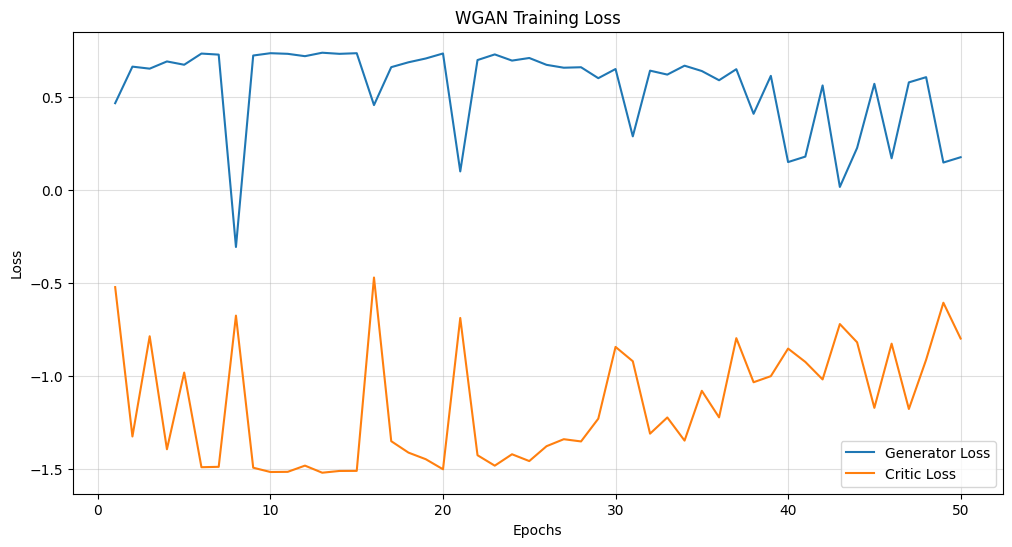

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd # Pandas makes reading CSVs and plotting easy

# --- Configuration ---
loss_file_path = "wgan_losses.csv"
output_plot_path = "Wgan_loss_plot_from_file.png"
# --- Main Script ---
try:
    # Read the data from the CSV file into a pandas DataFrame
    df = pd.read_csv(loss_file_path)

    # Check if the DataFrame is empty
    if df.empty:
        print(f"The loss file '{loss_file_path}' is empty. Nothing to plot.")
    else:
        print(f"Successfully loaded {len(df)} epochs from {loss_file_path}.")
        
        # Create the plot
        plt.figure(figsize=(12, 6))
        plt.plot(df["Epoch"], df["Generator_Loss"], label="Generator Loss")
        plt.plot(df["Epoch"], df["Critic_Loss"], label="Critic Loss")
        
        plt.title("WGAN Training Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, alpha=0.4)
        
        # Save the plot
        plt.savefig(output_plot_path)
        print(f"Plot saved successfully to '{output_plot_path}'")
        plt.show()

except FileNotFoundError:
    print(f"Error: The file '{loss_file_path}' was not found. Did the training script run?")
except Exception as e:
    print(f"An error occurred: {e}")

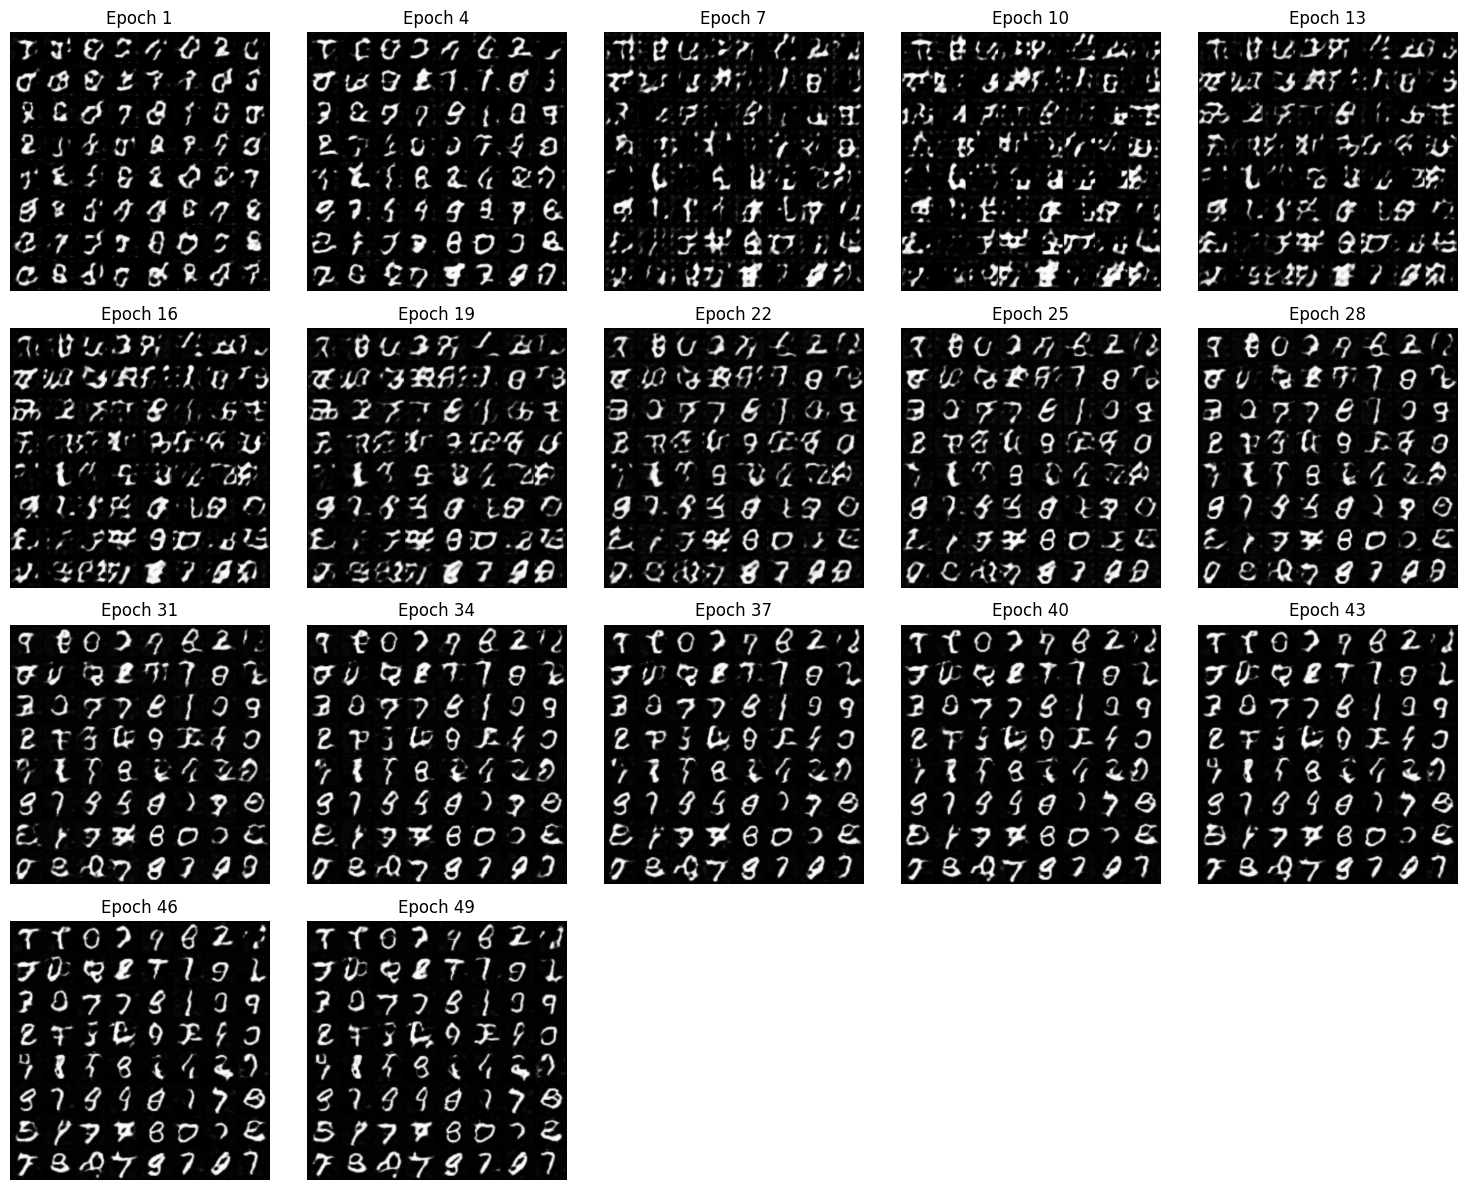

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = "gan_samples_WGAN"
epochs = 50
step = 3

# Collect epochs to display
selected_epochs = list(range(1, epochs+1, step))

# Calculate grid size
cols = 5  # number of images per row
rows = (len(selected_epochs) + cols - 1) // cols

# Prepare the figure
fig, axes = plt.subplots(rows, cols, figsize=(15, rows*3))

for idx, epoch in enumerate(selected_epochs):
    r = idx // cols
    c = idx % cols
    ax = axes[r, c] if rows > 1 else axes[c]

    img_path = os.path.join(folder, f"sample_epoch_{epoch}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"Epoch {epoch}")
    ax.axis('off')

# Turn off any empty subplots
for i in range(len(selected_epochs), rows*cols):
    r = i // cols
    c = i % cols
    ax = axes[r, c] if rows > 1 else axes[c]
    ax.axis('off')
plt.tight_layout()
plt.show()